In [1]:
import os
import copy
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Dataset

warnings.filterwarnings("ignore")

torch.manual_seed(42)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cpu


In [3]:
EUROSAT_PATH = "../dataset/EuroSAT"

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])
val_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [5]:
dataset = ImageFolder(EUROSAT_PATH)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_subset, val_subset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

In [6]:
class TransformDataset(Dataset):

    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):

        image, label = self.subset[index]

        image = self.transform(image)

        return image, label

In [7]:
train_dataset = TransformDataset(train_subset, train_transform)
val_dataset = TransformDataset(val_subset, val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Train Batches:", len(train_loader))
print("Validation Batches:", len(val_loader))

Train Batches: 675
Validation Batches: 169


In [8]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


In [9]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
model = BaselineCNN().to(device)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )

In [11]:
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input Shape :", images.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([32, 3, 128, 128])
Output Shape: torch.Size([32, 10])


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [13]:
loss = criterion(outputs, labels.to(device))

print("Loss:", loss.item())

Loss: 2.29787015914917


In [14]:
def train_model(model, train_loader, val_loader,
                criterion, optimizer,
                epochs=10):

    train_losses = []
    val_losses = []

    train_accs = []
    val_accs = []

    best_acc = 0

    for epoch in range(epochs):

        ##########################
        # Training
        ##########################

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)

        train_accuracy = 100 * correct / total

        ##########################
        # Validation
        ##########################

        model.eval()

        running_loss = 0

        correct = 0

        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, predicted = torch.max(outputs,1)

                total += labels.size(0)

                correct += (predicted==labels).sum().item()

        val_loss = running_loss / len(val_loader)

        val_accuracy = 100 * correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}]")

        print(f"Train Loss : {train_loss:.4f}")

        print(f"Train Acc  : {train_accuracy:.2f}%")

        print(f"Val Loss   : {val_loss:.4f}")

        print(f"Val Acc    : {val_accuracy:.2f}%")

        print("-"*50)

        if val_accuracy > best_acc:

            best_acc = val_accuracy

            torch.save(
                model.state_dict(),
                "../models/baseline_cnn.pth"
            )

    return train_losses, val_losses, train_accs, val_accs

In [15]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=5
)

Epoch [1/5]
Train Loss : 1.0941
Train Acc  : 59.52%
Val Loss   : 0.7647
Val Acc    : 74.31%
--------------------------------------------------
Epoch [2/5]
Train Loss : 0.6862
Train Acc  : 75.78%
Val Loss   : 0.5297
Val Acc    : 81.43%
--------------------------------------------------
Epoch [3/5]
Train Loss : 0.5388
Train Acc  : 81.31%
Val Loss   : 0.4580
Val Acc    : 84.11%
--------------------------------------------------
Epoch [4/5]
Train Loss : 0.4408
Train Acc  : 85.30%
Val Loss   : 0.4282
Val Acc    : 85.22%
--------------------------------------------------
Epoch [5/5]
Train Loss : 0.3679
Train Acc  : 87.78%
Val Loss   : 0.2910
Val Acc    : 89.78%
--------------------------------------------------


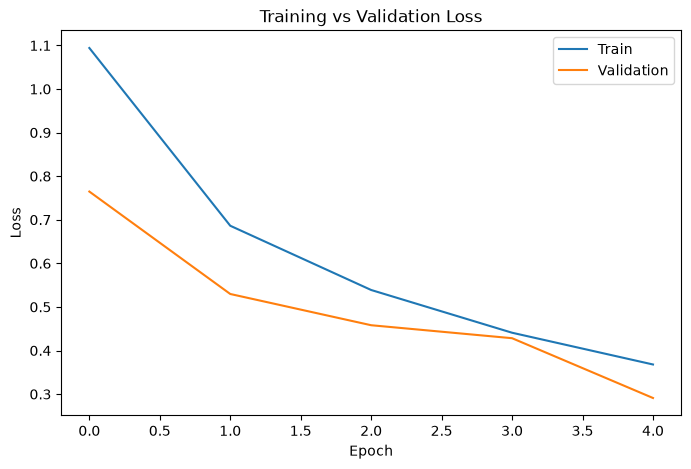

In [16]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Train")

plt.plot(val_losses,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

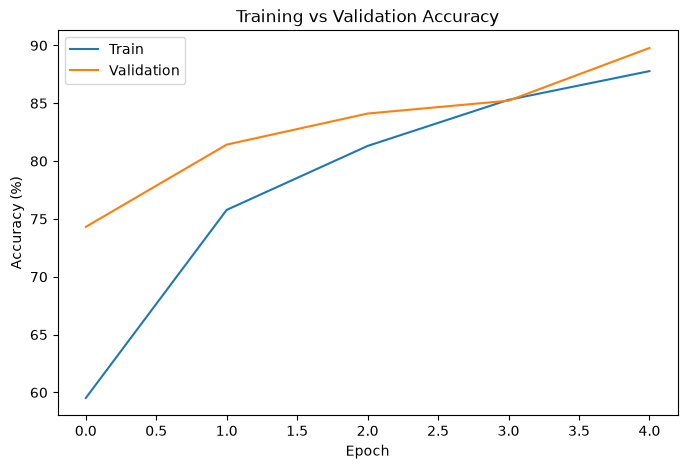

In [17]:
plt.figure(figsize=(8,5))

plt.plot(train_accs,label="Train")

plt.plot(val_accs,label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

In [18]:
model.load_state_dict(
    torch.load("../models/baseline_cnn.pth")
)

print("Best Model Loaded Successfully!")

Best Model Loaded Successfully!
